# Getting Started with Occhio

This tutorial walks through the core occhio workflow:

1. Define a **sparse feature distribution** that generates synthetic data
2. Train a **bottleneck autoencoder** that must compress more features than it has hidden dimensions
3. Inspect the learned **superposition geometry** -- the phenomenon where a network packs more features than it has dimensions by overlapping their representations

We use realistic experiment parameters: 50 sparse features compressed into 15 hidden dimensions, trained for 25,000 epochs.

In [1]:
import torch
import plotly.graph_objects as go
import plotly.io as pio

from occhio import ToyModel
from occhio.autoencoders import TiedLinearRelu
from occhio.distributions import SparseUniform
from occhio.visualization import (
    plot_embedding,
    plot_feature_norm_by_index,
    plot_feature_dimensionality_by_index,
    plot_representation,
)

pio.renderers.default = "png"
torch.manual_seed(42)

## 1. Experiment Parameters

The key ratio is `n_features / n_hidden = 50 / 15 ≈ 3.3x`. The autoencoder
must compress 50 features into 15 dimensions, forcing it to find clever
representational strategies. With `p_active = 0.01`, only ~0.5 features
fire per sample on average, which makes superposition viable.

In [2]:
n_features = 50
n_hidden = 15
p_active = 0.01
n_epochs = 25_000
batch_size = 1024
learning_rate = 3e-4

# Feature importances decay geometrically: feature 0 is most important,
# feature 49 is least. This mirrors real networks where some directions
# matter more than others.
importances = 0.9 ** torch.arange(n_features)

print(f"Compression ratio: {n_features / n_hidden:.1f}x")
print(f"Expected active features per sample: {n_features * p_active:.1f}")
print(
    f"Importance range: {importances[0]:.3f} (feature 0) -> {importances[-1]:.5f} (feature 49)"
)

Compression ratio: 3.3x
Expected active features per sample: 0.5
Importance range: 1.000 (feature 0) -> 0.00573 (feature 49)


## 2. Create the Distribution

`SparseUniform` generates samples where each feature independently fires
with probability `p_active`. When active, values are drawn from Uniform(0, 1).
This extreme sparsity (99% of features are zero in any sample) is what makes
superposition possible -- if features rarely co-occur, the network can afford
to let their representations overlap.

In [3]:
dist = SparseUniform(n_features=n_features, p_active=p_active, device="cpu")

# Peek at the data
samples = dist.sample(batch_size=10_000)
active_per_sample = (samples > 0).sum(dim=1).float()
print(f"Sample shape: {samples.shape}")
print(f"Mean active features per sample: {active_per_sample.mean():.2f}")
print(f"Fraction of zero entries: {(samples == 0).float().mean():.4f}")

Sample shape: torch.Size([10000, 50])
Mean active features per sample: 0.51
Fraction of zero entries: 0.9898


## 3. Create the Autoencoder

`TiedLinearRelu` is a single-layer autoencoder with tied weights:

    encode(x) = x @ W.T          (50 -> 15)
    decode(z) = ReLU(z @ W + b)   (15 -> 50)

The ReLU on the decoder is critical: it lets the network use **antipodal pairs**
(features pointing in opposite directions) because ReLU zeroes out the wrong
sign during reconstruction.

In [4]:
ae = TiedLinearRelu(n_features=n_features, n_hidden=n_hidden, device="cpu")

print(
    f"Architecture: {n_features} features -> {n_hidden} hidden -> {n_features} features"
)
print(f"Learnable parameters: {sum(p.numel() for p in ae.parameters())}")
print(f"  W: {n_hidden} x {n_features} = {n_hidden * n_features}")
print(f"  b: {n_features}")

Architecture: 50 features -> 15 hidden -> 50 features
Learnable parameters: 800
  W: 15 x 50 = 750
  b: 50


## 4. Train the Model

`ToyModel` ties together the distribution, autoencoder, and feature importances.
Training runs Adam optimization on weighted MSE loss for 25,000 epochs.

In [5]:
model = ToyModel(dist, ae, importances=importances, device="cpu")

losses, _ = model.fit(
    n_epochs=n_epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
)

print(f"Initial loss: {losses[0]:.6f}")
print(f"Final loss:   {losses[-1]:.6f}")
print(f"Reduction:    {losses[0] / losses[-1]:.0f}x")

Initial loss: 0.058345
Final loss:   0.000866
Reduction:    67x


## 5. Training Loss Curve

The loss should drop rapidly in the first few thousand epochs as the network
learns the dominant features, then continue improving slowly as it refines
representations for less important features.

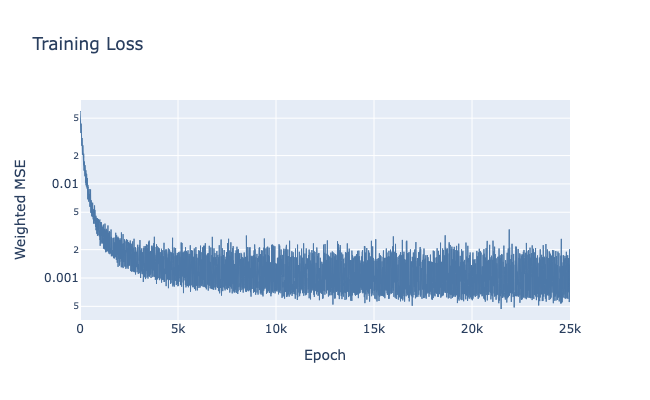

In [6]:
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        y=losses,
        mode="lines",
        line=dict(width=1, color="#4C78A8"),
        name="Training loss",
    )
)
fig.update_layout(
    title="Training Loss",
    xaxis_title="Epoch",
    yaxis_title="Weighted MSE",
    yaxis_type="log",
    height=400,
    width=650,
)
fig.show()

## 6. Key Metrics

After training, `ToyModel` exposes geometric properties that describe
how features are represented in the hidden space.

### Superposition

The superposition metric (rho_mm) is the mean maximum absolute cosine similarity
between feature embeddings. It ranges from 0 (all features orthogonal) to 1
(features fully overlapping). With 50 features in 15 dimensions and high sparsity,
we expect strong superposition.

In [7]:
rho = model.superposition.item()
print(f"Superposition (rho_mm): {rho:.4f}")
print(f"  With {n_features} features in {n_hidden} dims, the network")
print(f"  cannot make all features orthogonal -> high superposition.")

Superposition (rho_mm): 0.7366
  With 50 features in 15 dims, the network
  cannot make all features orthogonal -> high superposition.


### Feature Norms

The norm of each feature's embedding vector reflects how strongly it is
represented. Features with higher importance should have larger norms
(the network invests more capacity in features that matter more).
Features with near-zero norms have been effectively dropped.

Feature norms range: [0.0107, 1.1268]
Features with norm > 0.5: 44 / 50
Features with norm < 0.1: 6 / 50



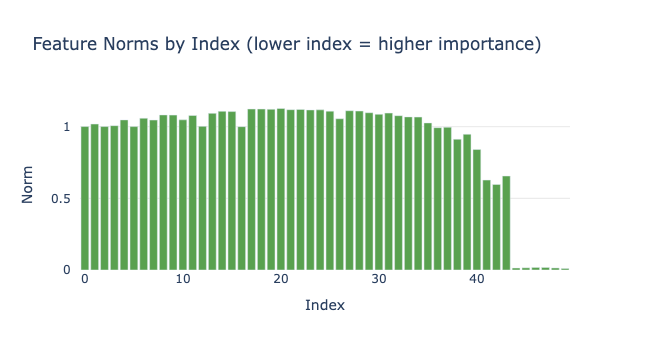

In [8]:
norms = model.feature_norms
print(f"Feature norms range: [{norms.min():.4f}, {norms.max():.4f}]")
print(f"Features with norm > 0.5: {(norms > 0.5).sum().item()} / {n_features}")
print(f"Features with norm < 0.1: {(norms < 0.1).sum().item()} / {n_features}")
print()

# Show the importance-dependent learning: higher importance -> higher norm
fig = plot_feature_norm_by_index(model)
fig.update_layout(
    title="Feature Norms by Index (lower index = higher importance)",
    height=350,
    width=650,
)
fig.show()

### Feature Dimensionalities

Each feature occupies some number of effective dimensions in the hidden space.
In a 15D space with 50 features, the average is 15/50 = 0.3 dims per feature
if all are represented equally. Highly superposed features share dimensions.

Mean dimensionality: 0.2969
Sum of dimensionalities: 14.8 (= n_hidden = 15)



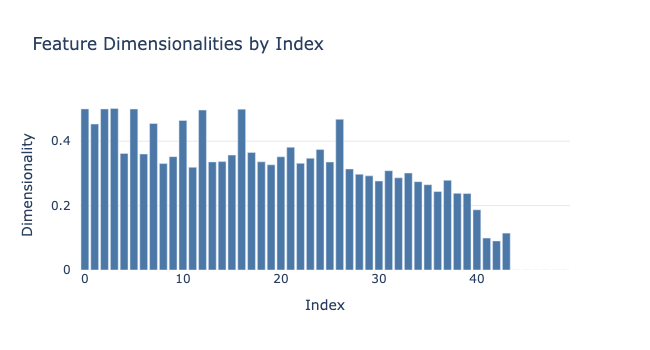

In [9]:
dims = model.feature_dimensionalities
print(f"Mean dimensionality: {dims.mean():.4f}")
print(f"Sum of dimensionalities: {dims.sum():.1f} (= n_hidden = {n_hidden})")
print()

fig = plot_feature_dimensionality_by_index(model)
fig.update_layout(
    title="Feature Dimensionalities by Index",
    height=350,
    width=650,
)
fig.show()

## 7. Visualize the Embedding

`plot_embedding` draws each feature's embedding as an arrow from the origin.
It requires a 2D hidden space, so we train a separate small model with
`n_hidden=2` to see the geometry directly.

With high sparsity, features spread out in many directions -- this is
superposition in action. With 50 features in 2D, the network must
heavily overlap representations.

2D model superposition: 0.9991
2D model features with norm > 0.5: 5 / 50


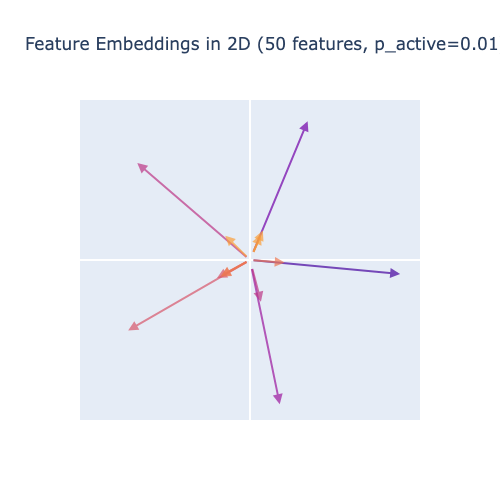

In [10]:
# Train a 2D model for direct visualization
torch.manual_seed(42)
dist_2d = SparseUniform(n_features=n_features, p_active=p_active, device="cpu")
ae_2d = TiedLinearRelu(n_features=n_features, n_hidden=2, device="cpu")
model_2d = ToyModel(dist_2d, ae_2d, importances=importances, device="cpu")

model_2d.fit(
    n_epochs=n_epochs,
    batch_size=batch_size,
    learning_rate=learning_rate,
)

print(f"2D model superposition: {model_2d.superposition.item():.4f}")
print(
    f"2D model features with norm > 0.5: {(model_2d.feature_norms > 0.5).sum().item()} / {n_features}"
)

fig = plot_embedding(model_2d)
fig.update_layout(
    title="Feature Embeddings in 2D (50 features, p_active=0.01)",
    height=500,
    width=500,
)
fig.show()

### Feature Interference Heatmap (15D Model)

For the full 15D model, we can visualize the Gram matrix W^T W to understand
feature interference. Diagonal entries show squared norms (representation
strength), off-diagonal entries show dot products between feature pairs
(interference). Important features (top-left) should have stronger diagonal
entries.

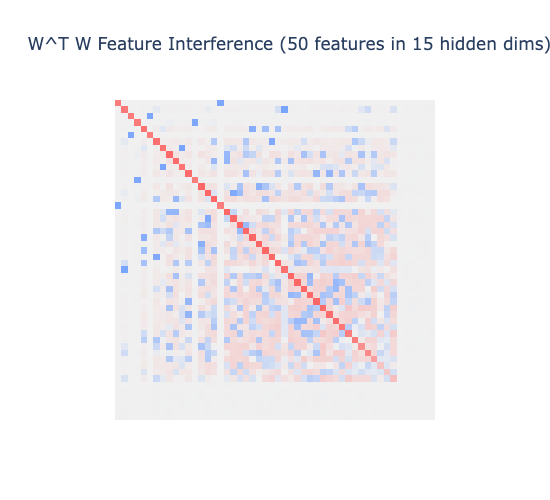

In [11]:
fig = plot_representation(model)
fig.update_layout(
    title="W^T W Feature Interference (50 features in 15 hidden dims)",
    height=500,
    width=550,
)
fig.show()

## Summary

This experiment demonstrated the core superposition phenomenon:

- **50 features compressed into 15 dimensions** -- a 3.3x compression ratio
- **High superposition** (rho_mm near 1.0) -- features must overlap because there aren't enough orthogonal directions
- **Importance-dependent learning** -- the network allocates more capacity (higher norms) to important features and may drop the least important ones entirely
- **Fractional dimensionalities** -- each feature occupies a fraction of a hidden dimension, with dimensionalities summing to exactly `n_hidden`

Next steps:
- Sweep sparsity and importance with `ModelGrid` (see `model_grid_sweeps.ipynb`)
- Explore correlated features with `CorrelatedPairs` (see `correlated_features.ipynb`)
- Compare autoencoder architectures (see `architecture_comparison.ipynb`)
- Study superposition geometry in detail (see `superposition_geometry.ipynb`)